# 02 - Model Training

This notebook provides an interactive workflow for training the EEGNet model on BCI Competition IIIa data.

## Overview
- Load preprocessed data
- Configure model architecture and hyperparameters
- Train EEGNet model
- Monitor training progress
- Save model checkpoint

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
import time

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from models.architectures.eegnet import EEGNet
from scripts.gpu_utils import get_optimal_device, print_cuda_diagnostics

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")

Project root: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline
PyTorch version: 2.11.0+cpu


## 1. Setup and Configuration

In [2]:
# Load configuration
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration:")
print(f"  Batch size: {config['training']['batch_size']}")
print(f"  Learning rate: {config['training']['learning_rate']}")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  Early stopping patience: {config['training']['early_stopping']['patience']}")

Configuration:
  Batch size: 32
  Learning rate: 0.001
  Epochs: 200
  Early stopping patience: 20


In [3]:
# Check GPU availability
print_cuda_diagnostics()

device = get_optimal_device(config['training']['gpu']['device'])
print(f"\nUsing device: {device}")


CUDA Diagnostics

PyTorch Version: 2.11.0+cpu
CUDA Available: False

[INFO] CUDA not available

To enable GPU acceleration:
   1. Install CUDA Toolkit: https://developer.nvidia.com/cuda-downloads
   2. Install CUDA-enabled PyTorch:
      pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

Alternatively, training can proceed on CPU (reduced performance expected)


Using device: cpu


## 2. Load Preprocessed Data

In [4]:
class BCIDataset(Dataset):
    """PyTorch Dataset for BCI Competition data."""
    
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        # Add channel dimension: (n_samples, 1, n_channels, n_timepoints)
        self.X = self.X.unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
# Select subject (change index to train on different subjects)
subject_idx = 0  # 0: k3b, 1: k6b, 2: l1b
subject_file = config['paths']['subjects'][subject_idx]
subject_id = Path(subject_file).stem

print(f"Training on subject: {subject_id}")

# Load preprocessed data
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
train_file = processed_dir / f"{subject_id}_train.npz"
val_file = processed_dir / f"{subject_id}_val.npz"

if not train_file.exists() or not val_file.exists():
    raise FileNotFoundError(
        f"Preprocessed data not found. Run: python scripts/1_preprocess_data.py"
    )

train_data = np.load(train_file)
val_data = np.load(val_file)

X_train = train_data['X']
y_train = train_data['y']
X_val = val_data['X']
y_val = val_data['y']

print(f"\nData loaded:")
print(f"  Training: {X_train.shape}, Labels: {y_train.shape}")
print(f"  Validation: {X_val.shape}, Labels: {y_val.shape}")

Training on subject: k3b

Data loaded:
  Training: (144, 60, 1001), Labels: (144,)
  Validation: (36, 60, 1001), Labels: (36,)


In [6]:
# Create datasets and dataloaders
batch_size = config['training']['batch_size']

train_dataset = BCIDataset(X_train, y_train)
val_dataset = BCIDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataloaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

Dataloaders created:
  Training batches: 5
  Validation batches: 2


## 3. Create Model

In [7]:
# Create EEGNet model
model = EEGNet(
    n_classes=config['model']['eegnet']['n_classes'],
    n_channels=config['model']['eegnet']['n_channels'],
    n_timepoints=config['model']['eegnet']['n_timepoints'],
    F1=config['model']['eegnet']['F1'],
    D=config['model']['eegnet']['D'],
    F2=config['model']['eegnet']['F2'],
    kernel_length=config['model']['eegnet']['kernel_length'],
    dropout=config['model']['eegnet']['dropout'],
    pool_size=config['model']['eegnet']['pool_size']
).to(device)

print("Model architecture:")
print(model)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

Model architecture:
EEGNet(
  (conv1): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_depthwise): Conv2d(8, 16, kernel_size=(60, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3_depthwise): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
  (conv3_pointwise): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=240, out_features=4, bias=True)
)

Trainable parameters: 3,028


## 4. Training Setup

In [8]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=config['training']['learning_rate'],
    weight_decay=config['training']['weight_decay']
)

# Learning rate scheduler (verbose parameter removed in PyTorch 2.x)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=config['training']['lr_scheduler']['factor'],
    patience=config['training']['lr_scheduler']['patience'],
    min_lr=config['training']['lr_scheduler']['min_lr']
)

print("Training setup complete")

Training setup complete


## 5. Training Functions

In [9]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

## 6. Train Model

In [10]:
# Training hyperparameters
epochs = config['training']['epochs']
early_stopping_patience = config['training']['early_stopping']['patience']

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0
patience_counter = 0

print(f"Starting training for {epochs} epochs...\n")
start_time = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_acc)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] ({epoch_time:.2f}s) | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        
        # Save checkpoint
        checkpoint_dir = PROJECT_ROOT / config['paths']['model_checkpoints']
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        checkpoint_path = checkpoint_dir / f"{subject_id}_best.pth"
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
            'config': config
        }, checkpoint_path)
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")
        break

total_time = time.time() - start_time
print(f"\nTraining complete")
print(f"Total time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")

Starting training for 200 epochs...

Epoch [  1/200] (0.66s) | Train Loss: 1.4177, Train Acc: 0.2431 | Val Loss: 1.3886, Val Acc: 0.3056
Epoch [ 10/200] (0.63s) | Train Loss: 1.0631, Train Acc: 0.6389 | Val Loss: 1.1349, Val Acc: 0.5278
Epoch [ 20/200] (0.64s) | Train Loss: 0.6854, Train Acc: 0.7083 | Val Loss: 0.7541, Val Acc: 0.5833
Epoch [ 30/200] (0.64s) | Train Loss: 0.5763, Train Acc: 0.7708 | Val Loss: 0.7369, Val Acc: 0.5833
Epoch [ 40/200] (0.67s) | Train Loss: 0.4301, Train Acc: 0.8194 | Val Loss: 0.6734, Val Acc: 0.6667
Epoch [ 50/200] (0.66s) | Train Loss: 0.2461, Train Acc: 0.9236 | Val Loss: 0.5744, Val Acc: 0.7778
Epoch [ 60/200] (0.64s) | Train Loss: 0.2043, Train Acc: 0.9236 | Val Loss: 0.4951, Val Acc: 0.8611
Epoch [ 70/200] (0.65s) | Train Loss: 0.1328, Train Acc: 0.9653 | Val Loss: 0.4843, Val Acc: 0.8333
Epoch [ 80/200] (0.65s) | Train Loss: 0.1298, Train Acc: 0.9653 | Val Loss: 0.4908, Val Acc: 0.8611
Epoch [ 90/200] (0.64s) | Train Loss: 0.0772, Train Acc: 0.9931

## 7. Visualize Training History

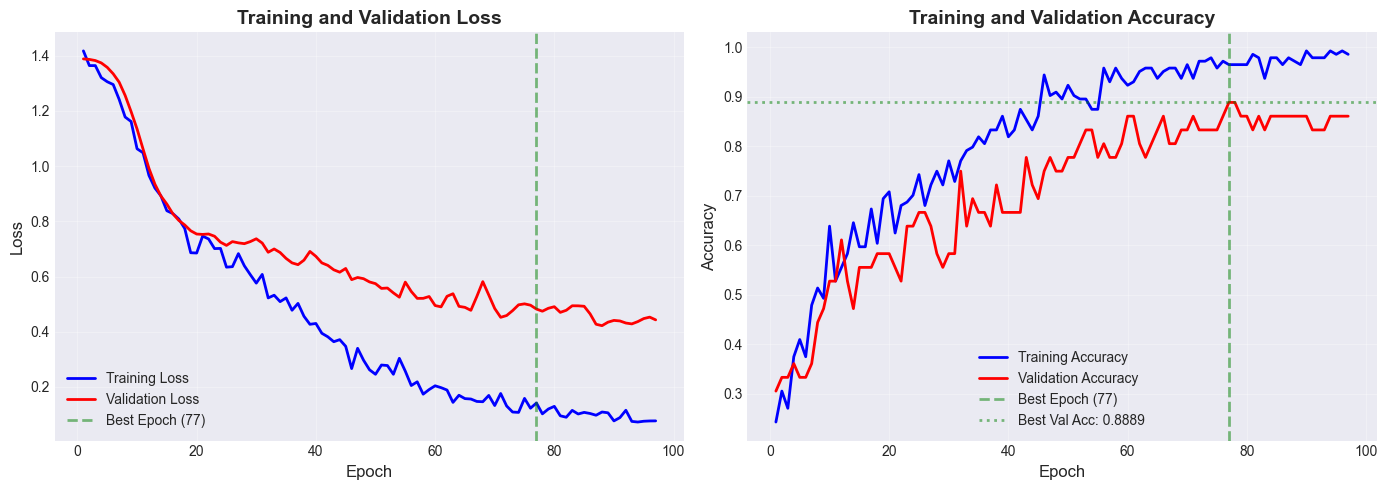

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax1.axvline(x=best_epoch + 1, color='green', linestyle='--', linewidth=2, 
            alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
ax2.axvline(x=best_epoch + 1, color='green', linestyle='--', linewidth=2, 
            alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
ax2.axhline(y=best_val_acc, color='green', linestyle=':', linewidth=2, 
            alpha=0.5, label=f'Best Val Acc: {best_val_acc:.4f}')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Save Training History

In [12]:
# Save training history
results_dir = PROJECT_ROOT / "results" / subject_id
results_dir.mkdir(parents=True, exist_ok=True)

history_path = results_dir / "training_history.npz"
np.savez(history_path, **history)

print(f"Training history saved to: {history_path}")
print(f"Model checkpoint saved to: {checkpoint_path}")

Training history saved to: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\results\k3b\training_history.npz
Model checkpoint saved to: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\models\saved_models\k3b_best.pth


## 9. Summary

Model training complete. Key metrics:
- Best validation accuracy achieved
- Model checkpoint saved
- Training history recorded

**Next step**: Evaluate the trained model using `03_evaluate_results.ipynb`